currently saving data is slow: 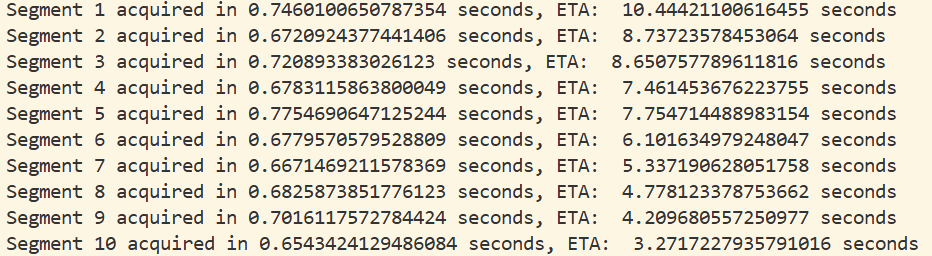

just moving some SCPI commands out of the loop helped: 
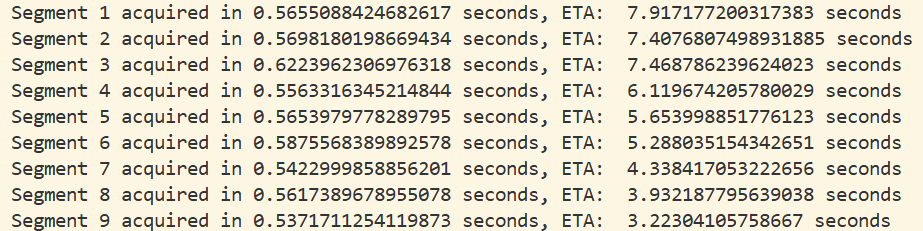

transporting data back with binary helped a lot, but this is not including time spent writing to disk
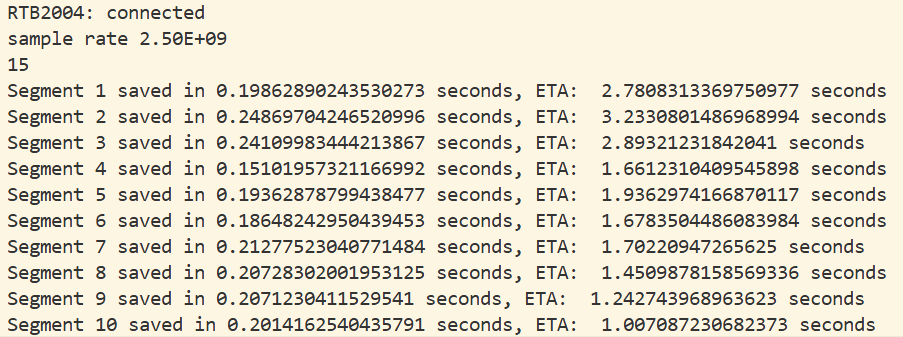

including writing to disk: 
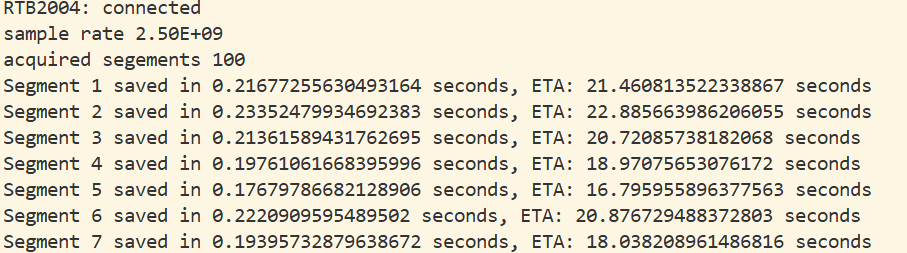

h5, etc. writing to disk in different ways didn't matter

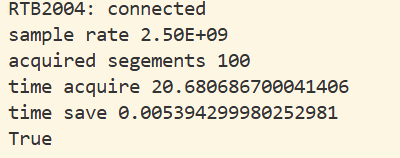
h5
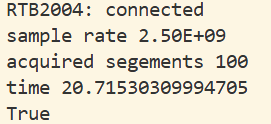

In [ ]:
import threading
import queue
import numpy as np
import h5py
import time

NUM_SAMPLES = 4096
BATCH_SIZE = 256

q = queue.Queue(maxsize=32)

def writer():
    with h5py.File("waveforms.h5", "w") as f:

        dset = f.create_dataset(
            "waveforms",
            shape=(0, NUM_SAMPLES),
            maxshape=(None, NUM_SAMPLES),
            dtype=np.float32,
            chunks=(BATCH_SIZE, NUM_SAMPLES)
        )

        timestamps = []
        total_segments = 0

        while True:
            batch = q.get()
            if batch is None:
                break
            n = batch.shape[0]
            dset.resize(total_segments + n, axis=0)
            dset[total_segments:total_segments+n] = batch

            timestamps.append((
                total_segments,
                time.time_ns()
            ))

            total_segments += n

            q.task_done()

        f.create_dataset(
            "timestamps",
            data=np.array(timestamps, dtype=np.int64)
        )

threading.Thread(target=writer, daemon=True).start()

while acquiring:
    batch = np.empty(
        (BATCH_SIZE, NUM_SAMPLES),
        dtype=np.float32
    )
    for i in range(BATCH_SIZE):
        batch[i] = acquire_segment()
    q.put(batch)

q.put(None)